In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [2]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

e:\anaconda3\envs\Graph_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\Stabilized_RK_Allen_Cahn_Cahn_Hillard\\SRK\\utils.py'>

In [3]:
#Time and space range
a_x = 0
b_x = 2
a_y = 0
b_y = 1
a_z = 0
b_z = 1

s = 10

#Initial x grid size and t grid size
Nx = 200
Ny = 100
Nz = 100

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)
dz = float64((b_z - a_z) / Nz)

T = 0.01
h = 1 / Nx
eps = 0.01
# dt = (s + 4) * (s - 1) * dx**2 / 12
dt = 1e-5
bc= "Periodic"
# bc = "Neumann"

print("Initial dt used is " + str(dt))
print("eps used is " + str(eps))

Initial dt used is 1e-05
eps used is 0.01


In [4]:
x_grid = np.linspace(a_x, b_x, Nx+1)
y_grid = np.linspace(a_y, b_y, Ny+1)
z_grid = np.linspace(a_z, b_z, Nz+1)

mesh_grid = np.meshgrid(x_grid, y_grid, z_grid)

In [5]:
X, Y, Z = mesh_grid
print(X[0, 0, 0], X[0, 1, 0])
print(Y[0, 0, 0], Y[1, 0, 0])
print(Z[0, 0, 0], Z[0, 0, 1])

0.0 0.01
0.0 0.01
0.0 0.01


Initial condition

In [6]:
'''
Initial Condition for the Allen-Cahn simulation
ϕ(x, y, z, 0) = 1.0, if (0.4 < x < 1.6) and (0.4 < y, z < 0.6)
              = 1 + tanh((R0 - sqrt((x-0.3)^2 + (y-0.5)^2 + (z-0.5)^2)) / (2*sqrt(ϵ))) 
                  + tanh((R0 - sqrt((x-1.7)^2 + (y-0.5)^2 + (z-0.5)^2)) / (2*sqrt(ϵ))), otherwise
'''
def initial_condition(mesh_grid, eps):
    X, Y, Z = mesh_grid
    
    # Parameters
    R0 = 0.25  # Radius of the spheres
    y_center = 0.5  # Center of y domain
    z_center = 0.5  # Center of z domain
    
    # Initialize result array
    result = np.zeros_like(X)
    
    # Condition: (0.4 < x < 1.6) and (0.4 < y < 0.6) and (0.4 < z < 0.6)
    condition = ((X > 0.4) & (X < 1.6) & 
                 (Y > 0.4) & (Y < 0.6) & 
                 (Z > 0.4) & (Z < 0.6))
    
    # Set to 1.0 where condition is true
    result[condition] = 1.0
    
    # For other points: use tanh formula
    YZ_sq = (Y - y_center)**2 + (Z - z_center)**2    
    # Distance from first sphere center (x=0.3)
    r1 = np.sqrt((X - 0.3)**2 + YZ_sq)
    # Distance from second sphere center (x=1.7)
    r2 = np.sqrt((X - 1.7)**2 + YZ_sq)
    
    # Compute tanh terms
    tanh_term1 = np.tanh((R0 - r1) / (np.sqrt(2) * eps))
    tanh_term2 = np.tanh((R0 - r2) / (np.sqrt(2) * eps))
    
    # Apply formula where condition is false
    result[~condition] = 1.0 + tanh_term1[~condition] + tanh_term2[~condition]
    
    return result

In [7]:
dumbbell_initial_condition = initial_condition(mesh_grid, eps)

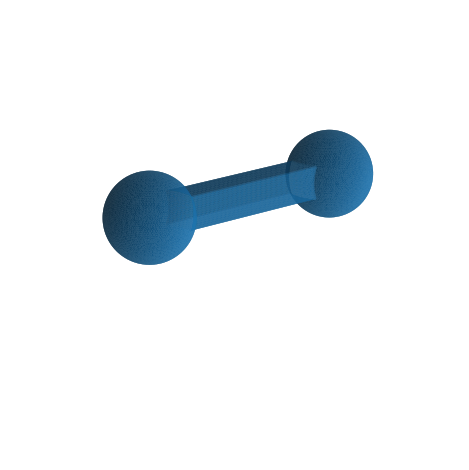

In [8]:
from skimage.measure import marching_cubes

level = 0.0
verts, faces, _, _ = marching_cubes(dumbbell_initial_condition, level=level)

# Convert voxel coords -> physical coords
sx = (x_grid.max() - x_grid.min()) / (Nx - 1)
sy = (y_grid.max() - y_grid.min()) / (Ny - 1)
sz = (z_grid.max() - z_grid.min()) / (Nz - 1)

verts_phys = np.column_stack([
    x_grid.min() + verts[:, 0] * sx,
    y_grid.min() + verts[:, 1] * sy,
    z_grid.min() + verts[:, 2] * sz
])

# --- Plot ---
fig = plt.figure(figsize=(6.5, 4.8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts_phys[:, 0], verts_phys[:, 1], faces, verts_phys[:, 2],
    linewidth=0.0, antialiased=True, shade=True
)

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_box_aspect((2, 1, 1))
ax.view_init(elev=15, azim=-45)  # nice paper-like angle
ax.set_axis_off()

plt.tight_layout()
# plt.savefig("dumbbell_initial_isosurface.png", dpi=300, bbox_inches="tight")
plt.show()

Simulation

In [9]:
# my_method = "RKL2_3D"
my_method = "RKG2_3D"

save = True
save_path = f"../../Results/Allen_Cahn_Dumbbell_3D/{my_method}"

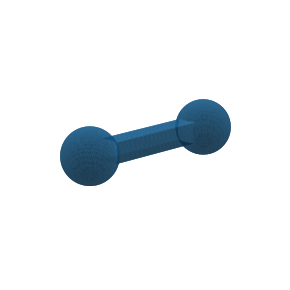

In [10]:
my_solver = solvers.Allen_Cahn_Solver_3D_Constant_Timestep(my_method, s, Nx, Ny, Nz, dt, dx, dy, dz, a_x, b_x, a_y, b_y, a_z, b_z, initial_condition, T, eps, bc=bc, plot_frequency=100, splitting_order="NLN", save=save, save_path=save_path)
my_solver.initialize(display=True)

Solving:   0%|                                                           | 0/1001 [00:00<?, ?iter/s]

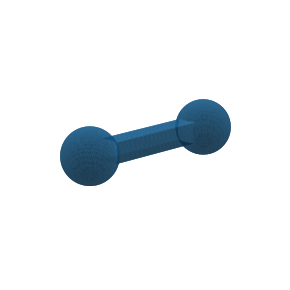

Solving:  10%|████▉                                            | 100/1001 [03:18<26:53,  1.79s/iter]

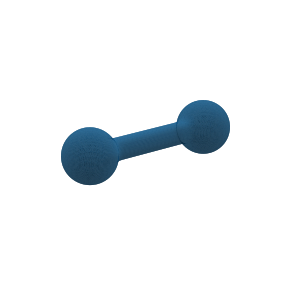

Solving:  20%|█████████▊                                       | 200/1001 [06:37<24:48,  1.86s/iter]

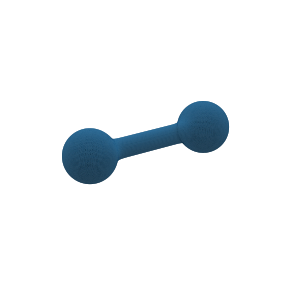

Solving:  30%|██████████████▋                                  | 300/1001 [10:03<27:14,  2.33s/iter]

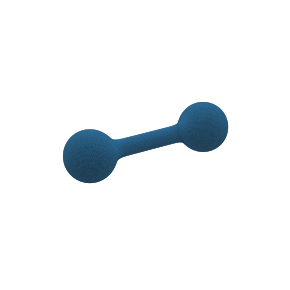

Solving:  40%|███████████████████▌                             | 400/1001 [13:23<18:24,  1.84s/iter]

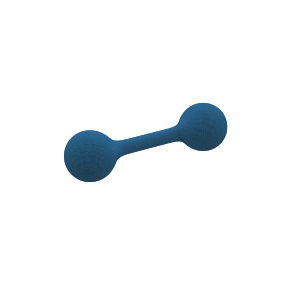

Solving:  50%|████████████████████████▍                        | 500/1001 [16:34<15:02,  1.80s/iter]

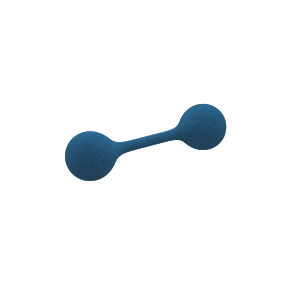

Solving:  60%|█████████████████████████████▎                   | 600/1001 [20:18<16:23,  2.45s/iter]

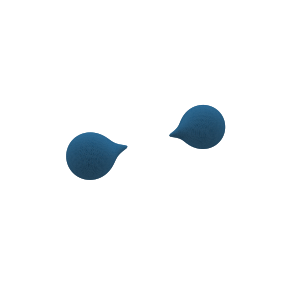

Solving:  70%|██████████████████████████████████▎              | 700/1001 [24:50<13:26,  2.68s/iter]

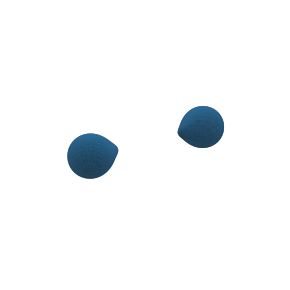

Solving:  80%|███████████████████████████████████████▏         | 800/1001 [29:13<08:30,  2.54s/iter]

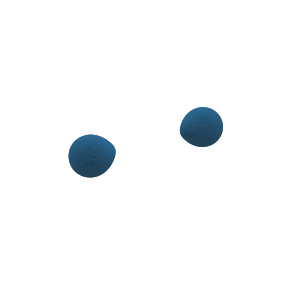

Solving:  90%|████████████████████████████████████████████     | 900/1001 [32:13<02:49,  1.67s/iter]

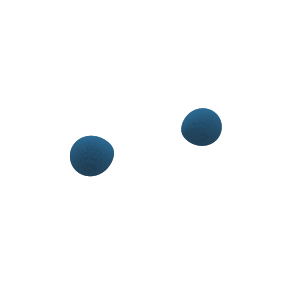

Solving: 100%|███████████████████████████████████████████████▉| 1000/1001 [34:55<00:01,  1.51s/iter]

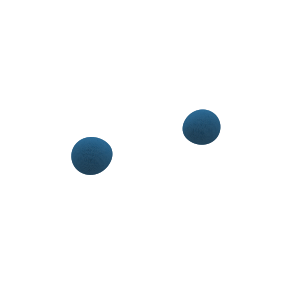

Solving: 100%|████████████████████████████████████████████████| 1001/1001 [35:01<00:00,  2.10s/iter]


In [11]:
my_solver.solve()

In [12]:
u_total, t_total, energy_total, mesh_grid = my_solver.get_results()

Figure saved to ../../Results/Allen_Cahn_Dumbbell_3D/RKG2_3D\RKG2_3D_Dumbbell_Nx200_Ny100_Nz100_dt1e-05_eps0.0100_T0.01_bcPeriodic.pdf


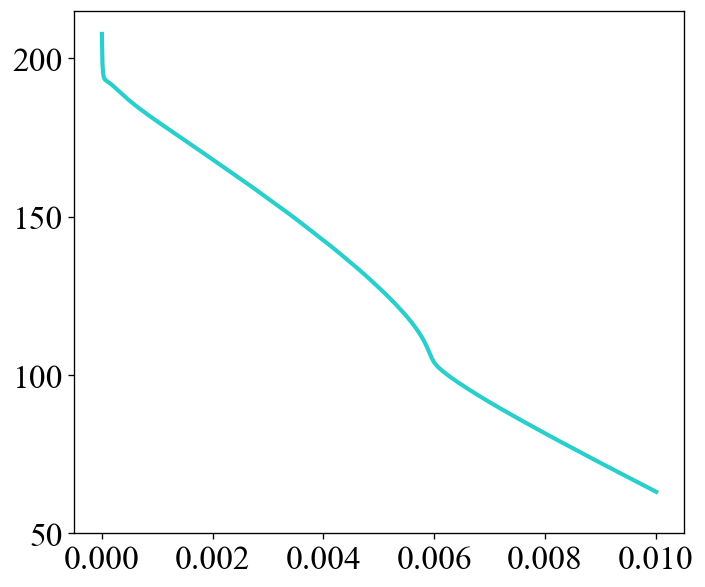

In [13]:
energy_gradient_total = energy_total[:, 0]
energy_non_linear_total = energy_total[:, 1]
energy = energy_gradient_total + energy_non_linear_total

# Journal of Computational Physics (Elsevier): Times New Roman for figures
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["mathtext.rm"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
# ax.plot(t_total, energy_gradient_total * dx**3, color="#2E86AB", lw=2, label="Gradient energy")
# ax.plot(t_total, energy_non_linear_total * dx**3, color="#A23B72", lw=2, label="Non-linear energy")
ax.plot(t_total[:], energy[:] * dx**3, color="#29cfcc", lw=2.5)

from matplotlib.ticker import FuncFormatter, MultipleLocator

config_title = f"{my_method}_Dumbbell_Nx{Nx}_Ny{Ny}_Nz{Nz}_dt{dt}_eps{eps:.4f}_T{T}_bc{bc}"


label_font = {"fontsize": 12, "fontfamily": "Times New Roman"}
# ax.set_xlabel("Time $t$", **label_font)
# ax.set_ylabel("Energy", **label_font)
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e3:.0f}"))
# ax.yaxis.set_major_locator(MultipleLocator(1000))
# ax.text(-0.01, 1.02, r"$\times\,10^{3}$",
#         transform=ax.transAxes,
#         fontsize=20,
#         fontfamily="Times New Roman",
#         va="bottom")
ax.tick_params(axis="both", labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
# ax.legend(loc="best", frameon=True, prop={"family": "serif", "size": 14})
# ax.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xticks([0, 0.002, 0.004, 0.006, 0.008, 0.01])
ax.set_yticks([50, 100, 150, 200])
fig.tight_layout()

if save:
    # save_path is ../../Results/... from the solver setup; mkdir so savefig never fails
    os.makedirs(save_path, exist_ok=True)
    energy_save_path = os.path.join(save_path, f"{config_title}.pdf")
    fig.savefig(energy_save_path, bbox_inches="tight")
    print(f"Figure saved to {energy_save_path}")
plt.show()